In [45]:
import os
import json
import torch
import torch.nn as nn
import numpy as np

import pandas as pd

from collections import defaultdict, Counter
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [2]:
with open('data/raw/instances_default.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

### Маппинг

In [3]:
annotations = data['annotations']
images = data['images']
categories = data['categories']

In [4]:
annotations[0]

{'id': 1,
 'image_id': 1,
 'category_id': 1,
 'segmentation': [],
 'area': 156929.9087,
 'bbox': [127.67, 437.45, 532.67, 294.61],
 'iscrowd': 0,
 'attributes': {'occluded': False, 'rotation': 0.0}}

In [5]:
images[0]

{'id': 1,
 'width': 1654,
 'height': 2339,
 'file_name': 'invoice_001.jpg',
 'license': 0,
 'flickr_url': '',
 'coco_url': '',
 'date_captured': 0}

In [6]:
categories[0]

{'id': 1, 'name': 'Seller', 'supercategory': ''}

In [7]:
image_id_to_name = {
    img['id']: img['file_name'] for img in images
}

In [8]:
category_id_to_name = {
    category['id']: category['name'] for category in categories
}

category_id_to_name

{1: 'Seller',
 2: 'Invoice_number',
 3: 'Invoice_date',
 4: 'Total_amount',
 5: 'Item_description'}

In [9]:
label2id = {
    category['name']: category['id'] - 1 for category in categories
}

label2id

{'Seller': 0,
 'Invoice_number': 1,
 'Invoice_date': 2,
 'Total_amount': 3,
 'Item_description': 4}

In [10]:
ALLOWED_LABELS = {
    category['name'] for category in categories
}

ALLOWED_LABELS

{'Invoice_date',
 'Invoice_number',
 'Item_description',
 'Seller',
 'Total_amount'}

### Группировка аннотаций по картинкам

In [11]:
dataset = defaultdict(lambda: {
    'bboxes': [],
    'labels': []
})

for ann in annotations:
    image_id = ann['image_id']
    bbox = ann['bbox']
    label = category_id_to_name[ann['category_id']]

    dataset[image_id]['bboxes'].append(bbox)
    dataset[image_id]['labels'].append(label)

next(iter(dataset.items()))

(1,
 {'bboxes': [[127.67, 437.45, 532.67, 294.61],
   [135.2, 824.3, 1387.46, 267.79],
   [484.57, 1320.82, 1029.23, 64.48],
   [115.76, 124.99, 892.75, 71.42],
   [120.7, 50.2, 445.47, 64.3]],
  'labels': ['Seller',
   'Item_description',
   'Total_amount',
   'Invoice_date',
   'Invoice_number']})

In [12]:
final_dataset = []

for image_id, data_item in dataset.items():
    final_dataset.append({
        'image_path': f'images/{image_id_to_name[image_id]}',
        'bboxes': data_item['bboxes'],
        'labels': data_item['labels']
    })
    
final_dataset[0]

{'image_path': 'images/invoice_001.jpg',
 'bboxes': [[127.67, 437.45, 532.67, 294.61],
  [135.2, 824.3, 1387.46, 267.79],
  [484.57, 1320.82, 1029.23, 64.48],
  [115.76, 124.99, 892.75, 71.42],
  [120.7, 50.2, 445.47, 64.3]],
 'labels': ['Seller',
  'Item_description',
  'Total_amount',
  'Invoice_date',
  'Invoice_number']}

### Проверка консистентности датасета

In [13]:
def check_dataset_consistency(final_dataset, base_dir="data/raw"):
    problems = {
        'missing_keys': [],
        'length_mismatch': [],
        'file_not_found': [],
        'image_open_error': [],
        'empty_annotations': [],
        'invalid_bbox_format': [],
        'bbox_out_of_bounds': [],
        'invalid_labels':[],
    }

    class_counter = Counter()
    images_per_class = Counter()

    for idx, sample in enumerate(final_dataset):
        sample_id = f'sample_{idx}'

        # Проверка ключей
        required_keys = {'image_path', 'bboxes', 'labels'}
        missing = required_keys - set(sample.keys())
        if missing:
            problems['missing_keys'].append((sample_id, missing))
            continue

        image_path = Path(base_dir) / sample['image_path']
        bboxes = sample['bboxes']
        labels = sample['labels']

        # Проверка длины массива bboxes и длины массива labels
        if len(bboxes) != len(labels):
            problems['length_mismatch'].append((str(image_path), len(bboxes), len(labels)))

        # Проверка файлов на ошибку
        if not image_path.exists():
            problems['file_not_found'].append(str(image_path))

        # Проверка файла на битость
        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception as e:
            problems['image_open_error'].append((str(image_path), str(e)))
            continue

        # Проверка пустых аннотаций
        if len(bboxes) == 0 or len(labels) == 0:
            problems['empty_annotations'].append(str(image_path))

        # Проверка bbox
        sample_classes = set()

        for bbox, label in zip(bboxes, labels):
            # labels
            if label not in ALLOWED_LABELS:
                problems['invalid_labels'].append((str(image_path), label))

            class_counter[label] += 1
            sample_classes.add(label)

            # bbox format
            if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
                problems['invalid_bbox_format'].append((str(image_path), bbox))
                continue

            x, y, w, h = bbox

            # bbox bounds
            if x + w > width or y + h > height:
                problems["bbox_out_of_bounds"].append(
                    (str(image_path), bbox, (width, height))
                )
                
        for cls in sample_classes:
            images_per_class[cls] += 1
            
    return problems, class_counter, images_per_class

In [14]:
problems, class_counter, images_per_class = check_dataset_consistency(final_dataset)

print("=== Problems ===")
for issue_name, items in problems.items():
    print(f"{issue_name}: {len(items)}")

print("\n=== OBJECT COUNT BY CLASS ===")
for cls, count in class_counter.items():
    print(f"{cls}: {count}")

print("\n=== IMAGES COUNT BY CLASS ===")
for cls, count in images_per_class.items():
    print(f"{cls}: {count}")

=== Problems ===
missing_keys: 0
length_mismatch: 0
file_not_found: 0
image_open_error: 0
empty_annotations: 0
invalid_bbox_format: 0
bbox_out_of_bounds: 0
invalid_labels: 0

=== OBJECT COUNT BY CLASS ===
Seller: 1500
Item_description: 1500
Total_amount: 1498
Invoice_date: 1484
Invoice_number: 1484

=== IMAGES COUNT BY CLASS ===
Invoice_number: 1484
Item_description: 1500
Seller: 1500
Total_amount: 1498
Invoice_date: 1484


In [15]:
def find_duplicate_bboxes(final_dataset):
    duplicates = []

    for sample in final_dataset:
        image_path = sample['image_path']
        seen = set()

        for bbox, label in zip(sample['bboxes'], sample['labels']):
            key = (round(bbox[0], 2), round(bbox[1], 2), round(bbox[2], 2), round(bbox[3], 2), label)
            if key in seen:
                duplicates.append((image_path, bbox, label))
            seen.add(key)

    return duplicates

In [16]:
duplicates = find_duplicate_bboxes(final_dataset)
duplicates[:10]

[]

- пути к файлам валидны
- картинки открываются
- lengths совпадают
- bbox не выходят за границы
- labels корректные
- пустых аннотаций нет
- дублей нет

### Кодирование классов

In [17]:
final_dataset_encoded = []

for sample in final_dataset:
    encoded_sample = {
        "image_path": sample["image_path"],
        "bboxes": sample["bboxes"],
        "labels": [label2id[label] for label in sample["labels"]]
    }
    final_dataset_encoded.append(encoded_sample)

final_dataset_encoded[0]

{'image_path': 'images/invoice_001.jpg',
 'bboxes': [[127.67, 437.45, 532.67, 294.61],
  [135.2, 824.3, 1387.46, 267.79],
  [484.57, 1320.82, 1029.23, 64.48],
  [115.76, 124.99, 892.75, 71.42],
  [120.7, 50.2, 445.47, 64.3]],
 'labels': [0, 4, 3, 2, 1]}

### Разбивает на train, test, val

In [18]:
ids = list(range(len(final_dataset_encoded)))

train_idx, temp_idx = train_test_split(
    ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

train_data = [final_dataset_encoded[i] for i in train_idx]
val_data = [final_dataset_encoded[i] for i in val_idx]
test_data = [final_dataset_encoded[i] for i in test_idx]

print(len(train_data), len(val_data), len(test_data))

1050 225 225


In [19]:
split_dir = Path('data/interim')
split_dir.mkdir(parents=True, exist_ok=True)

with open(split_dir / 'train_idx.json', 'w', encoding='utf-8') as f:
    json.dump(train_idx, f)

with open(split_dir / 'val_idx.json', 'w', encoding='utf-8') as f:
    json.dump(val_idx, f)

with open(split_dir / "test_idx.json", "w", encoding="utf-8") as f:
    json.dump(test_idx, f)

### Dataset (“данные как поток для модели”)

In [24]:
class InvoiceDataset(Dataset):
    def __init__(self, data, images_dir, images_size=512):
        self.data = data
        self.images_dir = Path(images_dir)
        self.img_size = images_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample= self.data[idx]

        image_path = self.images_dir / Path(sample['image_path']).name

        image = Image.open(image_path).convert('RGB')
        orig_w, orig_h = image.size

        image = image.resize((self.img_size, self.img_size))

        boxes = []
        for bbox in sample['bboxes']:
            x, y, w, h = bbox

            x = x * self.img_size / orig_w
            y = y * self.img_size / orig_h
            w = w * self.img_size / orig_w
            h = h * self.img_size / orig_h

            boxes.append([x, y, x + w, y + h])

        boxes = torch.tensor(boxes, dtype=torch.float32)

        labels = torch.tensor(sample["labels"], dtype=torch.long)

        image = np.array(image) / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [26]:
dataset = InvoiceDataset(train_data, images_dir="data/raw/images")

image, target = dataset[0]

print(image.shape)
print(target["boxes"])
print(target["labels"])

torch.Size([3, 512, 512])
tensor([[ 40.0809,  29.5380, 309.8064,  40.1873],
        [ 41.4460,  95.4675, 198.4480, 157.2578],
        [ 41.3407, 181.6516, 469.4365, 225.0699],
        [154.1882, 279.5708, 466.7187, 288.0618],
        [ 37.3630,  12.9368, 167.0222,  25.1775]])
tensor([2, 0, 4, 3, 1])


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [28]:
def visualize_dataset_sample(dataset, idx=0):
    image, target = dataset[idx]

    image = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(8, 10))
    ax.imshow(image)

    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1, str(label.item()), color='blue')

    plt.show()

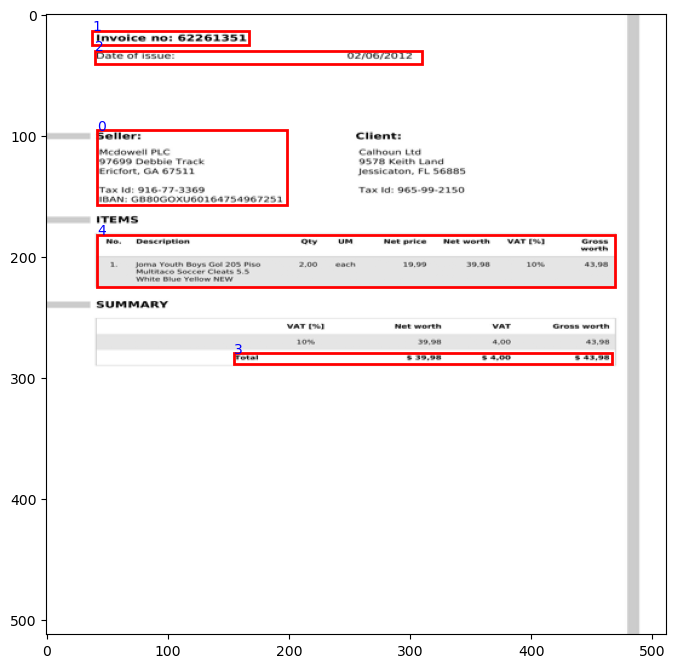

In [29]:
visualize_dataset_sample(dataset)

In [41]:
def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, list(targets)

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

### Backbone + proposal head + target builder

#### Backbone

In [33]:
import torch
import torch.nn as nn

class SimpleBackbone(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # 512 - 256

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), # 256 - 128

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), # 128 - 64

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 - 32

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.features(x)

#### Proposal Head
- 1 канал objectness
- 4 канала bbox offsets

In [34]:
class ProposalHead(nn.Module):
    def __init__(self, in_channels=256):
        super().__init__()

        self.head = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 5, kernel_size=1)
        )

    def forward(self, x):
        out = self.head(x)
        obj_logits = out[:, 0:1, :, :]
        bbox_reg = out[:, 1:5, :, :]
        return obj_logits, bbox_reg

In [35]:
class Stage1ProposalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SimpleBackbone()
        self.proposal_head = ProposalHead(in_channels=256)

    def forward(self, x):
        features = self.backbone(x)
        obj_logits, bbox_reg = self.proposal_head(features)
        return obj_logits, bbox_reg

In [37]:
model = Stage1ProposalNet()

x = torch.randn(2, 3, 512, 512)
obj_logits, bbox_reg = model(x)

print("obj_logits:", obj_logits.shape)
print("bbox_reg:", bbox_reg.shape)

obj_logits: torch.Size([2, 1, 32, 32])
bbox_reg: torch.Size([2, 4, 32, 32])


In [39]:
def build_stage1_targets(targets, img_size=512, grid_size=32, device="cpu"):
    batch_size = len(targets)
    cell_size = img_size / grid_size

    obj_target = torch.zeros((batch_size, 1, grid_size, grid_size), dtype=torch.float32, device=device)
    box_target = torch.zeros((batch_size, 4, grid_size, grid_size), dtype=torch.float32, device=device)
    box_mask = torch.zeros((batch_size, 1, grid_size, grid_size), dtype=torch.float32, device=device)

    for b_idx, target in enumerate(targets):
        boxes = target["boxes"] # формат [x1, y1, x2, y2]

        for box in boxes:
            x1, y1, x2, y2 = box.tolist()

            cx = (x1 + x2) / 2.0
            cy = (y1 + y2) / 2.0
            w = x2 - x1
            h = y2 - y1

            grid_x = int(cx / cell_size)
            grid_y = int(cy / cell_size)

            grid_x = min(grid_x, grid_size - 1)
            grid_y = min(grid_y, grid_size - 1)

            # смещение центра внутри ячейки [0..1]
            tx = (cx - grid_x * cell_size) / cell_size
            ty = (cy - grid_y * cell_size) / cell_size

            # размеры нормируем на размер изображения
            tw = w / img_size
            th = h / img_size

            obj_target[b_idx, 0, grid_y, grid_x] = 1.0
            box_target[b_idx, :, grid_y, grid_x] = torch.tensor([tx, ty, tw, th], device=device)
            box_mask[b_idx, 0, grid_y, grid_x] = 1.0

    return obj_target, box_target, box_mask

In [40]:
class Stage1Loss(nn.Module):
    def __init__(self, lambda_obj=1.0, lambda_box=5.0):
        super().__init__()
        self.lambda_obj = lambda_obj
        self.lambda_box = lambda_box
        self.obj_loss_fn = nn.BCEWithLogitsLoss()
        self.box_loss_fn = nn.SmoothL1Loss(reduction="none")

    def forward(self, pred_obj_logits, pred_box_reg, obj_target, box_target, box_mask):
        # objectness loss
        obj_loss = self.obj_loss_fn(pred_obj_logits, obj_target)

        # bbox loss только там, где есть объект
        box_loss_raw = self.box_loss_fn(pred_box_reg, box_target)  # [B,4,S,S]
        box_mask_expanded = box_mask.expand_as(box_loss_raw)
        box_loss = (box_loss_raw * box_mask_expanded).sum()

        num_pos = box_mask.sum().clamp(min=1.0)
        box_loss = box_loss / num_pos

        total_loss = self.lambda_obj * obj_loss + self.lambda_box * box_loss

        return total_loss, {
            "obj_loss": obj_loss.item(),
            "box_loss": box_loss.item(),
            "total_loss": total_loss.item()
        }

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Stage1ProposalNet().to(device)
criterion = Stage1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

images, targets = next(iter(train_loader))
images = images.to(device)

targets = [
    {
        "boxes": t["boxes"].to(device),
        "labels": t["labels"].to(device)
    }
    for t in targets
]

obj_target, box_target, box_mask = build_stage1_targets(
    targets,
    img_size=512,
    grid_size=32,
    device=device
)

pred_obj_logits, pred_box_reg = model(images)

loss, loss_dict = criterion(
    pred_obj_logits,
    pred_box_reg,
    obj_target,
    box_target,
    box_mask
)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(loss_dict)

{'obj_loss': 0.6318652629852295, 'box_loss': 0.3958905339241028, 'total_loss': 2.6113178730010986}


In [43]:
print(images.shape)
print(pred_obj_logits.shape)
print(pred_box_reg.shape)
print(obj_target.shape)
print(box_target.shape)
print(box_mask.shape)
print("positive cells:", box_mask.sum().item())

torch.Size([4, 3, 512, 512])
torch.Size([4, 1, 32, 32])
torch.Size([4, 4, 32, 32])
torch.Size([4, 1, 32, 32])
torch.Size([4, 4, 32, 32])
torch.Size([4, 1, 32, 32])
positive cells: 20.0


In [44]:
val_dataset = InvoiceDataset(val_data, images_dir="data/raw/images")
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [46]:
def train_one_epoch(model, loader, optimizer, criterion, device, img_size=512, grid_size=32):
    model.train()

    running_total = 0.0
    running_obj = 0.0
    running_box = 0.0

    for images, targets in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)

        targets = [
            {
                "boxes": t["boxes"].to(device),
                "labels": t["labels"].to(device)
            }
            for t in targets
        ]

        obj_target, box_target, box_mask = build_stage1_targets(
            targets=targets,
            img_size=img_size,
            grid_size=grid_size,
            device=device
        )

        pred_obj_logits, pred_box_reg = model(images)

        loss, loss_dict = criterion(
            pred_obj_logits,
            pred_box_reg,
            obj_target,
            box_target,
            box_mask
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_total += loss_dict["total_loss"]
        running_obj += loss_dict["obj_loss"]
        running_box += loss_dict["box_loss"]

    num_batches = len(loader)

    return {
        "total_loss": running_total / num_batches,
        "obj_loss": running_obj / num_batches,
        "box_loss": running_box / num_batches
    }

In [47]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, img_size=512, grid_size=32):
    model.eval()

    running_total = 0.0
    running_obj = 0.0
    running_box = 0.0

    for images, targets in tqdm(loader, desc="Val", leave=False):
        images = images.to(device)

        targets = [
            {
                "boxes": t["boxes"].to(device),
                "labels": t["labels"].to(device)
            }
            for t in targets
        ]

        obj_target, box_target, box_mask = build_stage1_targets(
            targets=targets,
            img_size=img_size,
            grid_size=grid_size,
            device=device
        )

        pred_obj_logits, pred_box_reg = model(images)

        loss, loss_dict = criterion(
            pred_obj_logits,
            pred_box_reg,
            obj_target,
            box_target,
            box_mask
        )

        running_total += loss_dict["total_loss"]
        running_obj += loss_dict["obj_loss"]
        running_box += loss_dict["box_loss"]

    num_batches = len(loader)

    return {
        "total_loss": running_total / num_batches,
        "obj_loss": running_obj / num_batches,
        "box_loss": running_box / num_batches
    }

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Stage1ProposalNet().to(device)
criterion = Stage1Loss(lambda_obj=1.0, lambda_box=5.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [50]:
num_epochs = 10
best_val_loss = float("inf")
history = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        img_size=512,
        grid_size=32
    )

    val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        img_size=512,
        grid_size=32
    )

    history.append({
        "epoch": epoch + 1,
        "train_total_loss": train_metrics["total_loss"],
        "train_obj_loss": train_metrics["obj_loss"],
        "train_box_loss": train_metrics["box_loss"],
        "val_total_loss": val_metrics["total_loss"],
        "val_obj_loss": val_metrics["obj_loss"],
        "val_box_loss": val_metrics["box_loss"],
    })

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_total={train_metrics['total_loss']:.4f}, "
        f"train_obj={train_metrics['obj_loss']:.4f}, "
        f"train_box={train_metrics['box_loss']:.4f} | "
        f"val_total={val_metrics['total_loss']:.4f}, "
        f"val_obj={val_metrics['obj_loss']:.4f}, "
        f"val_box={val_metrics['box_loss']:.4f}"
    )

    if val_metrics["total_loss"] < best_val_loss:
        best_val_loss = val_metrics["total_loss"]
        torch.save(model.state_dict(), "best_stage1.pt")
        print("  -> saved best_stage1.pt")

Epoch 1/10 | train_total=0.2342, train_obj=0.0324, train_box=0.0404 | val_total=0.1887, val_obj=0.0246, val_box=0.0328
  -> saved best_stage1.pt


Epoch 2/10 | train_total=0.1657, train_obj=0.0216, train_box=0.0288 | val_total=0.1598, val_obj=0.0196, val_box=0.0280
  -> saved best_stage1.pt


Epoch 3/10 | train_total=0.1479, train_obj=0.0180, train_box=0.0260 | val_total=0.1399, val_obj=0.0168, val_box=0.0246
  -> saved best_stage1.pt


Epoch 4/10 | train_total=0.1337, train_obj=0.0152, train_box=0.0237 | val_total=0.1475, val_obj=0.0148, val_box=0.0265


Epoch 5/10 | train_total=0.1254, train_obj=0.0132, train_box=0.0224 | val_total=0.1338, val_obj=0.0127, val_box=0.0242
  -> saved best_stage1.pt


Epoch 6/10 | train_total=0.1172, train_obj=0.0116, train_box=0.0211 | val_total=0.1486, val_obj=0.0118, val_box=0.0274


Epoch 7/10 | train_total=0.1112, train_obj=0.0105, train_box=0.0201 | val_total=0.1237, val_obj=0.0105, val_box=0.0226
  -> saved best_stage1.pt


Epoch 8/10 | train_total=0.1056, train_obj=0.0095, train_box=0.0192 | val_total=0.1305, val_obj=0.0111, val_box=0.0239


Epoch 9/10 | train_total=0.1028, train_obj=0.0091, train_box=0.0187 | val_total=0.1180, val_obj=0.0094, val_box=0.0217
  -> saved best_stage1.pt


Epoch 10/10 | train_total=0.0985, train_obj=0.0086, train_box=0.0180 | val_total=0.1216, val_obj=0.0092, val_box=0.0225
